# Univariate EDA — Titanic Dataset

**Purpose**: Understand the individual distribution, spread, and shape of each variable in the Titanic dataset in isolation (not relationships between variables — that's for bivariate/multivariate analysis later).

This includes:

- Checking data completeness (missing values)
- Examining categorical variables (Survived, Pclass, Embarked, Sex) via frequency counts and their visual distributions (countplots, pie charts)
- Examining numerical variables (Age, Fare, SibSp, Parch) via central tendency, spread, skewness/kurtosis, and shape (histograms, KDE/distplots, boxplots, violin plots)

- Detecting outliers using the IQR method
- Checking normality assumptions (QQ plot) and cumulative behavior (CDF plot) for Age

**Goal**: Build a variable-by-variable understanding of the data before moving to relationships between variables, and flag data quality issues (missing values, outliers, skew) that'll need handling before modeling.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Importing Dataset

In [2]:
df = pd.read_csv('../data/Titanic.csv')
df.head()

#NOTE: p=1 -> elite class , Cabin -->for p1 only 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Check for Null Values

In [3]:

data_null = df.isnull().sum()
perc = df.isnull().sum() / len(df) * 100


print("Null Values: \n",data_null)
print("---"*20)
print(f"Percentage Null :\n {perc}")


Null Values: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
------------------------------------------------------------
Percentage Null :
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


### Analysis
Checked for missing values across all columns, both as raw counts and as a percentage of total records. This helps identify which columns need imputation, dropping, or special handling before further analysis — for example, `Cabin` is expected to have a very high missing percentage (consistent with the earlier note that it's mostly populated for first-class passengers), while `Age` and `Embarked` typically show smaller, more manageable gaps in the Titanic dataset.

## 1. Categorical Data

### A. Countplot

Survived
0    549
1    342
Name: count, dtype: int64


<Axes: xlabel='Survived'>

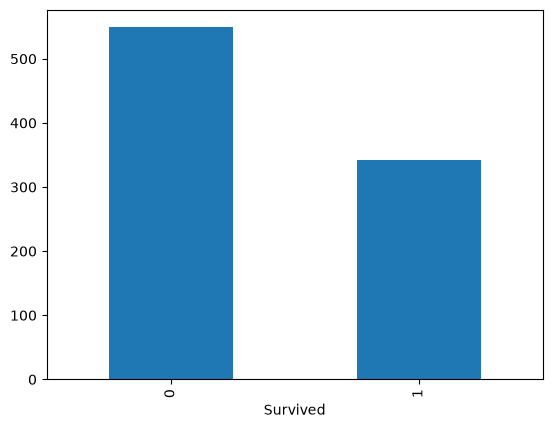

In [4]:
# Countplot
count = df['Survived'].value_counts(normalize=False)
print(count)

df['Survived'].value_counts().plot(kind='bar')


### Analysis
Examined the distribution of the target variable `Survived` using raw value counts and a bar plot. This shows the class balance between passengers who survived (1) and those who didn't (0) — an important check before modeling, since a skewed class distribution can affect model performance and evaluation metric choice (e.g., accuracy vs. F1-score).

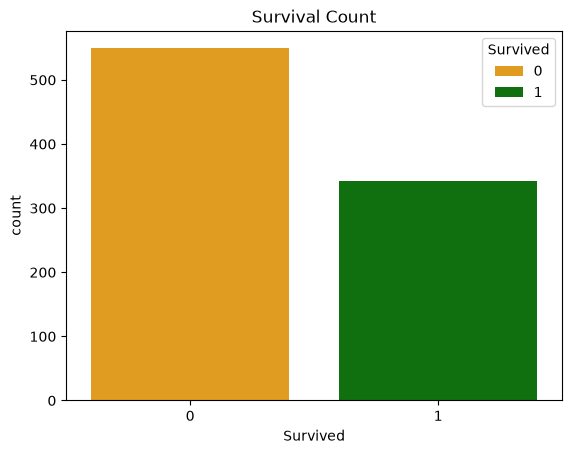

In [5]:
# Another Method 
sns.countplot(x='Survived', data=df, hue='Survived', palette=['orange', 'green'])  # Use x='Survived', data=df
plt.title('Survival Count')
plt.show()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


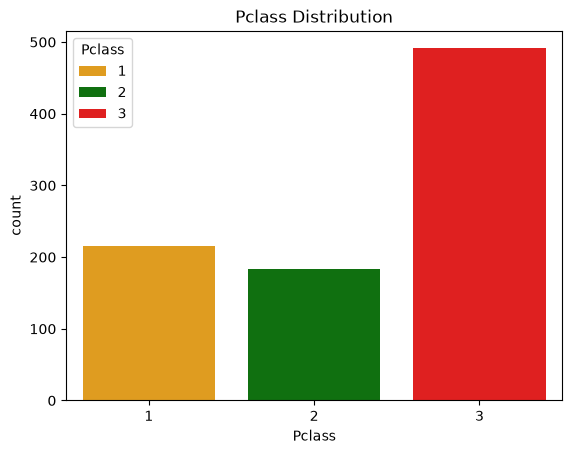

In [6]:
# For Pclass

#count
count = df['Pclass'].value_counts(normalize=False)
print(count)

#plot
sns.countplot(x='Pclass', data=df, hue='Pclass', palette=['orange', 'green','red'])  # Use x='Survived', data=df
plt.title('Pclass Distribution')
plt.show()

### Analysis

Examined the distribution of `Pclass` (passenger class) using value counts and a countplot. This shows how many passengers traveled in each class (1st, 2nd, 3rd), typically revealing that 3rd class had the largest share of passengers — useful context given that class is often linked to survival outcomes and other factors like fare and cabin availability.


Out of 891 passengers, the class split is: **3rd class = 491 (55.1%)**, **1st class = 216 (24.2%)**, **2nd class = 184 (20.7%)**. Third class alone outnumbers 1st and 2nd combined — a reflection of the ship's actual passenger demographics, where the majority were immigrants/working-class travelers in steerage.

**Hidden implication :** since `Pclass` is a strong proxy for socioeconomic status, and earlier we noted `Cabin` data exists almost exclusively for `Pclass = 1`, this heavy skew toward 3rd class is also *why* the `Cabin` column had ~77% missing values — most passengers simply weren't assigned/recorded cabins. This distribution will also matter directly for bivariate analysis, since historically 1st class had a much higher survival rate — worth flagging now as a variable to test against `Survived` later.

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


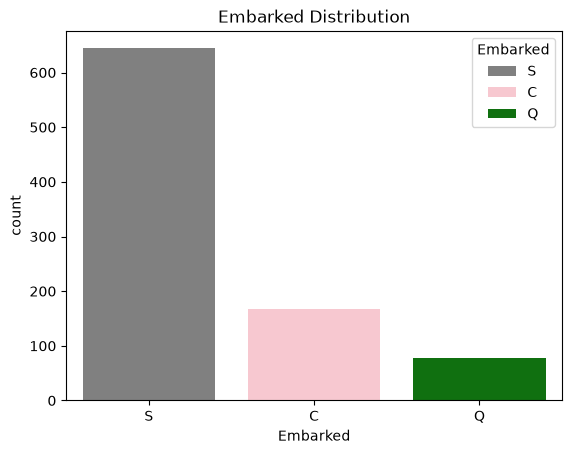

In [ ]:
# For Embark

#count
count = df['Embarked'].value_counts(normalize=False)
print(count)

#plot
sns.countplot(x='Embarked', data=df, hue='Embarked', palette=['gray', 'pink', 'green'])  # Use x='Survived', data=df
plt.title('Embarked Distribution')
plt.show()

### Analysis
Passengers embarked from three ports: **Southampton (S) = 644 (72.3%)**, **Cherbourg (C) = 168 (18.9%)**, **Queenstown (Q) = 77 (8.6%)**. Southampton dominates as the main departure port, consistent with the Titanic's origin in England.

**Hidden implication:** `Embarked` has only 2 missing values (seen in the null-check earlier), so it's a near-complete column — cheap to impute (mode = 'S') without much distortion. It's also historically correlated with `Pclass` and `Fare` (Cherbourg passengers tended to be wealthier, more 1st class), so it may carry indirect survival signal despite seeming like a minor categorical feature — worth testing in bivariate analysis rather than dropping outright.

### B. PieChart

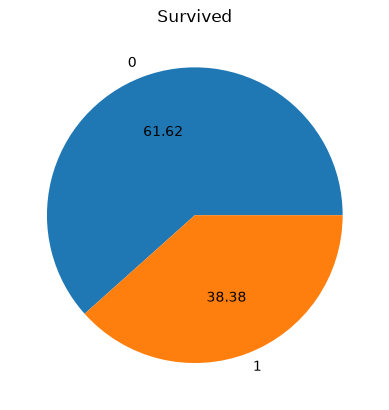

In [ ]:
# For Survived (percentage)
df['Survived'].value_counts().plot(kind = 'pie', autopct = '%.2f')
plt.title("Survived")
plt.show()

### Analysis
Of 891 passengers, **549 (61.6%) did not survive** and **342 (38.4%) survived** — confirming the class imbalance seen earlier in the countplot, now expressed as exact percentages via the pie chart.

**Hidden implication:** a ~62/38 split isn't extreme, but it's imbalanced enough that accuracy alone would be a misleading metric for a survival-prediction model later (a model predicting "did not survive" for everyone would already score ~61.6% accuracy). Precision, recall, F1, or ROC-AUC will be more meaningful evaluation choices downstream.

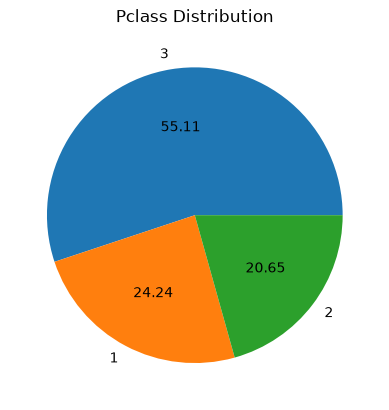

In [ ]:
# For Pclass (percentage)
df['Pclass'].value_counts().plot(kind = 'pie', autopct = '%.2f')
plt.title("Pclass Distribution")
plt.show()

### Analysis
Restates the `Pclass` distribution as percentages via pie chart: **3rd class = 55.11%**, **1st class = 24.24%**, **2nd class = 20.65%** (matching the counts from the earlier countplot: 491/216/184 out of 891).

**Hidden implication:** the pie chart doesn't add new information over the countplot numerically, but it emphasizes proportion at a glance — useful for quickly communicating "more than half the ship was 3rd class" to a non-technical audience, which reinforces why `Pclass` is worth treating as an important socioeconomic signal in later survival analysis.

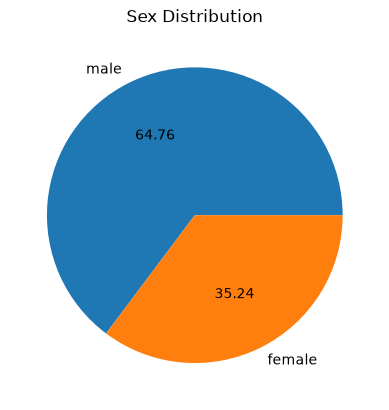

In [ ]:
# For Sex Distribution (Percentage)

df['Sex'].value_counts().plot(kind = 'pie', autopct = '%.2f')
plt.title("Sex Distribution")
plt.show()

### Analysis
Gender split is **male = 577 (64.8%)** and **female = 314 (35.2%)** — nearly two-thirds of passengers were male.

**Hidden implication:** despite males being the majority on board, the historical "women and children first" evacuation protocol means `Sex` is expected to be one of the strongest predictors of `Survived` (females had a much higher survival rate despite being the minority group) — this imbalance in `Sex` combined with the imbalance in `Survived` (61.6% did not survive) hints that survival was *not* proportionally distributed across genders, which bivariate analysis will confirm quantitatively.

## 2. Numerical Data 

### A. Histogram

Mean Age : 29.6991
Standard Deviation : 14.5265


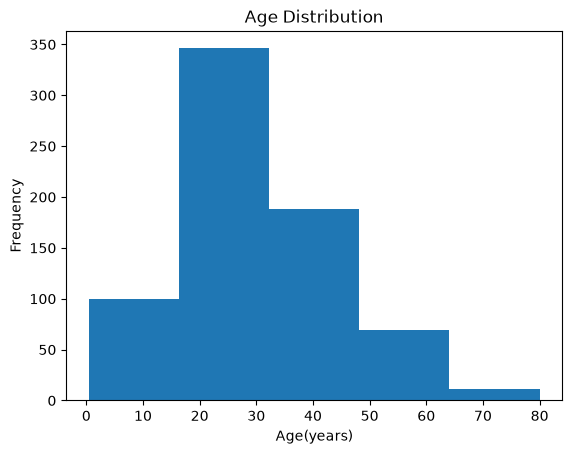

In [85]:
age = df['Age'].mean()
age_std = df['Age'].std()
print(f"Mean Age : {age:.4f}")
print(f"Standard Deviation : {age_std:.4f}")


plt.hist(df['Age'], bins=5)
plt.title('Age Distribution')
plt.xlabel('Age(years)')
plt.ylabel('Frequency')
plt.show()

### Analysis
**Mean Age = 29.70 years**, **Standard Deviation = 14.53 years**. The average passenger was around 30, with a fairly wide spread (±14.5 years) — meaning ages ranged broadly across children, young adults, and older passengers rather than clustering tightly around the mean.

**Hidden implication:** this mean/std is computed only on the 714 non-null `Age` records (177 missing, ~19.9% as seen in the null check) — so it's an estimate based on ~80% of the data, not the full population. Any imputation strategy (mean/median fill) should account for this gap, and a std this large relative to the mean (CV ≈ 49%) suggests `Age` isn't tightly concentrated, which should show up as a fairly spread-out histogram rather than a sharp peak.

**Note on histogram:** plotted with only 5 bins, which is coarse for an age range spanning 0–80 — this will produce broad buckets that can mask finer distribution details (e.g., separating infants from young children, or distinguishing sub-groups within the 20–40 range). A higher bin count (15–20) would show the shape more precisely, especially any right-skew from a long tail of older passengers.

### B. Distplot 

In [9]:
# Compute skewness and kurtosis
df[['Age','Fare']].kurtosis()

Age      0.178274
Fare    33.398141
dtype: float64

In [10]:
df[['Age','Fare']].skew()

Age     0.389108
Fare    4.787317
dtype: float64

### Analysis
**Skewness:** `Age = 0.389` (slightly right-skewed), `Fare = 4.787` (heavily right-skewed).
**Kurtosis:** `Age = 0.178` (close to normal, slightly flatter than a normal distribution), `Fare = 33.398` (extremely leptokurtic — sharp peak with very heavy tails).

**Hidden implication:** `Age`'s numbers (skew ≈ 0.39, kurtosis ≈ 0.18) are close enough to 0 that it's reasonably well-behaved and near-normal — mean/median imputation for the 177 missing values won't distort it much. `Fare`, on the other hand, is a red flag: a kurtosis of 33 is extreme (normal distribution has kurtosis 0) and confirms a small number of very high-fare passengers (likely 1st class) are pulling the distribution's tail out far — this is a strong signal of significant outliers in `Fare` that will show up clearly in the upcoming boxplot/IQR analysis, and suggests `Fare` will need a log-transform or outlier-capping before use in modeling rather than being used raw.

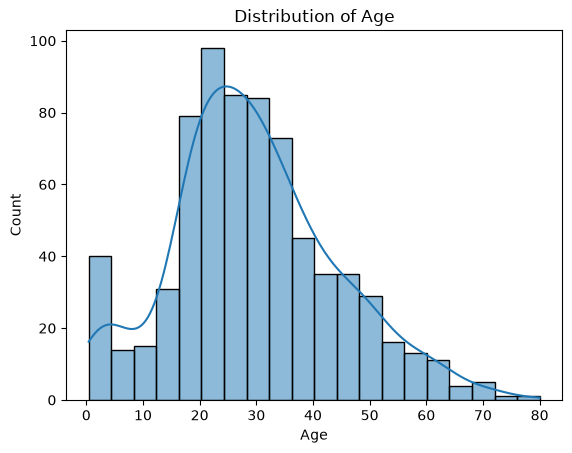

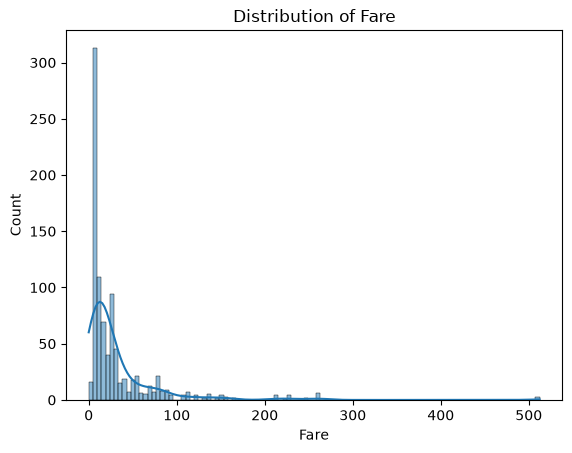

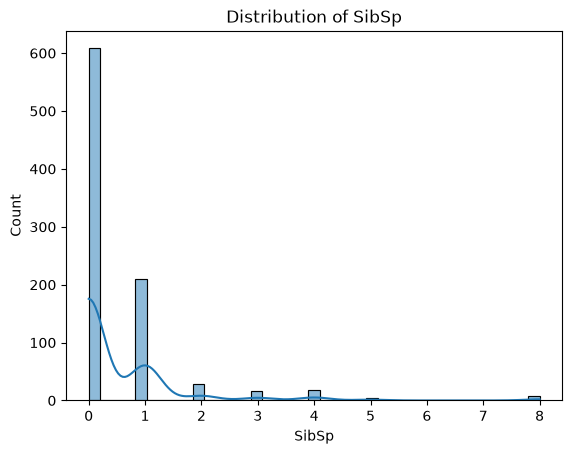

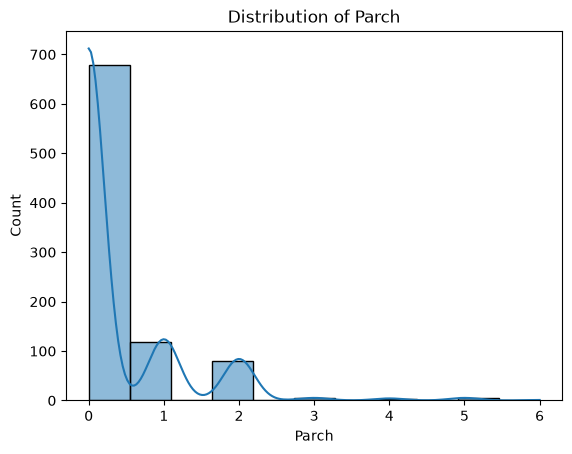

In [87]:
num_cols = ['Age','Fare','SibSp','Parch']
for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Analysis
Plotted histograms with KDE overlays for all four numerical columns (`Age`, `Fare`, `SibSp`, `Parch`), each with `.dropna()` applied so missing values don't distort the shape. This visually confirms the skew/kurtosis numbers from the previous cell: `Age` should appear roughly bell-shaped with a mild right tail, while `Fare` should show a sharp spike near lower values with a long thin tail stretching toward the extreme high fares.

**Hidden implication:** `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) are shown here as continuous histograms, but they're actually discrete count variables with a small range of values (mostly 0–4, with rare higher values) — a KDE curve on count data like this can be visually misleading, implying smoothness/continuity that doesn't exist. A better fit for these two would be a countplot or discrete bar histogram (`bins` aligned to integers) rather than a continuous density estimate.

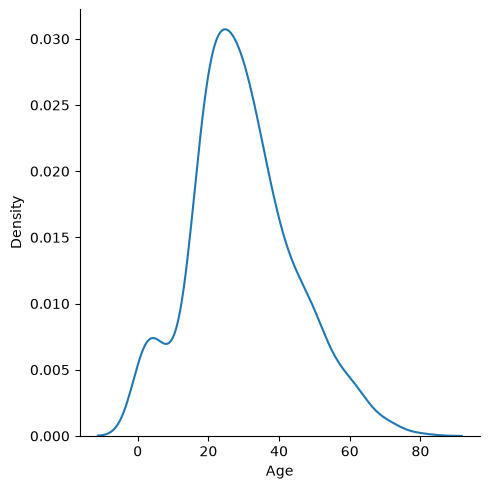

In [ ]:
sns.displot(x='Age', data=df, kind='kde') # Only kernel density estimation (KDE)
plt.show()

### Analysis
Plots a pure KDE curve for `Age` , giving a smoothed view of its density. This should show a single broad peak around the late-20s/early-30s (consistent with the mean of ~29.7), with a mild right-leaning tail extending toward older passengers — matching the slightly positive skew (0.389) computed earlier.

**Hidden implication:** this is somewhat redundant with the `sns.histplot(..., kde=True)` version from the previous cell, since that already overlaid a KDE on top of the histogram for `Age`. The main added value here is isolating the smooth density curve without bar-width/bin-count artifacts, which is useful for visually judging normality before running a formal test — a good visual segue into the QQ plot later in

### C. Boxplot

0.38910778230082704

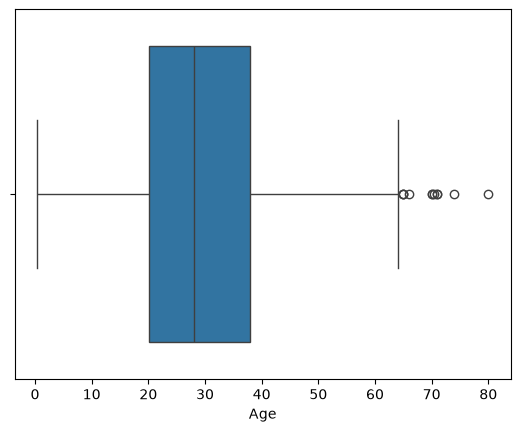

In [39]:
sns.boxplot(x='Age', data=df)
df['Age'].skew()

### Analysis
Boxplot of `Age` confirms the skewness value of **0.389** (slight right skew) computed earlier. The box (IQR) should sit roughly between the 20s and high-30s with the median near 28, and any outlier points beyond the whiskers would represent unusually old passengers (toward the 65–80 range), since the right tail is the longer one.

**Hidden implication:** unlike `Fare` (kurtosis ≈ 33, clearly outlier-heavy), `Age`'s mild skew and near-normal kurtosis (0.178) suggest its boxplot will show relatively few, mild outliers — meaning `Age` likely won't need aggressive outlier treatment, reinforcing that mean/median imputation for its 177 missing values is a safe choice going forward.

In [89]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


### Analysis
Encoded `Sex` from categorical strings to numeric (`male` -> 0, `female` -> 1) so it can be used in later statistical/plotting functions and eventually in modeling, which require numeric input.

**Hidden implication:** this is a preprocessing step tucked inside the EDA notebook rather than a pure analysis step — worth flagging that from this point onward, `Sex` is numeric (0/1), so any earlier-style `sns.countplot(x='Sex', ...)` calls using the original string labels ('male'/'female') would no longer render with readable category names unless explicitly relabeled. Also worth noting this hardcoded mapping assumes only two values are present in `Sex` — if the raw data ever contained an unexpected third value (typo, missing category, etc.), it would silently become `NaN` here rather than raising an error.

In [90]:
df = df.drop(columns=['Name','Ticket','Cabin', 'Embarked','PassengerId'])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000
887,1,1,1,19.0,0,0,30.0000
888,0,3,1,NaN,1,2,23.4500
889,1,1,0,26.0,0,0,30.0000


### Analysis
Dropped five columns: `Name`, `Ticket`, `Cabin`, `Embarked`, `PassengerId`. This leaves `df` with 7 columns: `Survived`, `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`.

**Hidden implication:** a few of these drops are consequential for later stages, not just cleanup. `Cabin` is dropped entirely rather than engineered — reasonable given its ~77% missing rate, but it discards the earlier insight that `Cabin`-presence itself correlates with `Pclass = 1` (a binary "has_cabin" flag could have preserved that signal instead of losing it outright). `Embarked` is also dropped despite having only 2 missing values and a plausible link to `Pclass`/`Fare`/survival noted earlier — so any predictive signal from departure port is now lost for this dataset going forward. Worth deciding if this was intentional simplification for univariate EDA purposes, or if these two should be reconsidered before moving to modeling.

In [ ]:
df[['Age','Fare','SibSp','Parch']].describe()
#df.describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


### Analysis
Summary statistics confirm earlier findings and add new detail: `Age` ranges 0.42–80 years (mean 29.7, median 28 — close together, consistent with its mild skew). `Fare` ranges $0–$512.33 with mean $32.20 but median only $14.45 — the mean being more than double the median is a direct numeric confirmation of the heavy right-skew (4.79) and extreme kurtosis (33.4) seen earlier. `SibSp` and `Parch` are both heavily zero-inflated (75th percentile still 0–1), confirming most passengers traveled alone or with very few relatives.

**Hidden implication:** the `Fare` max of **$512.33** is a massive outlier — over 16x the mean and over 35x the median — and almost certainly belongs to a first-class passenger, since it's known from Titanic records to be associated with the Cardeza family's suite ticket. A single value this extreme can heavily distort any model relying on raw `Fare` (e.g., inflating variance, skewing distance-based algorithms) — strong evidence that capping, log-transforming, or binning `Fare` will be necessary before modeling, not just noting the skew descriptively.

/var/folders/t6/83ml_h093hb2vy010z1bgz_m0000gn/T/ipykernel_3852/2408741938.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(data, vert=False)   # or use orientation='horizontal' to avoid deprecation warning
/var/folders/t6/83ml_h093hb2vy010z1bgz_m0000gn/T/ipykernel_3852/2408741938.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(data, vert=False)   # or use orientation='horizontal' to avoid deprecation warning
/var/folders/t6/83ml_h093hb2vy010z1bgz_m0000gn/T/ipykernel_3852/2408741938.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(data, vert=False)   # or use orientation='horizontal' to avoid dep

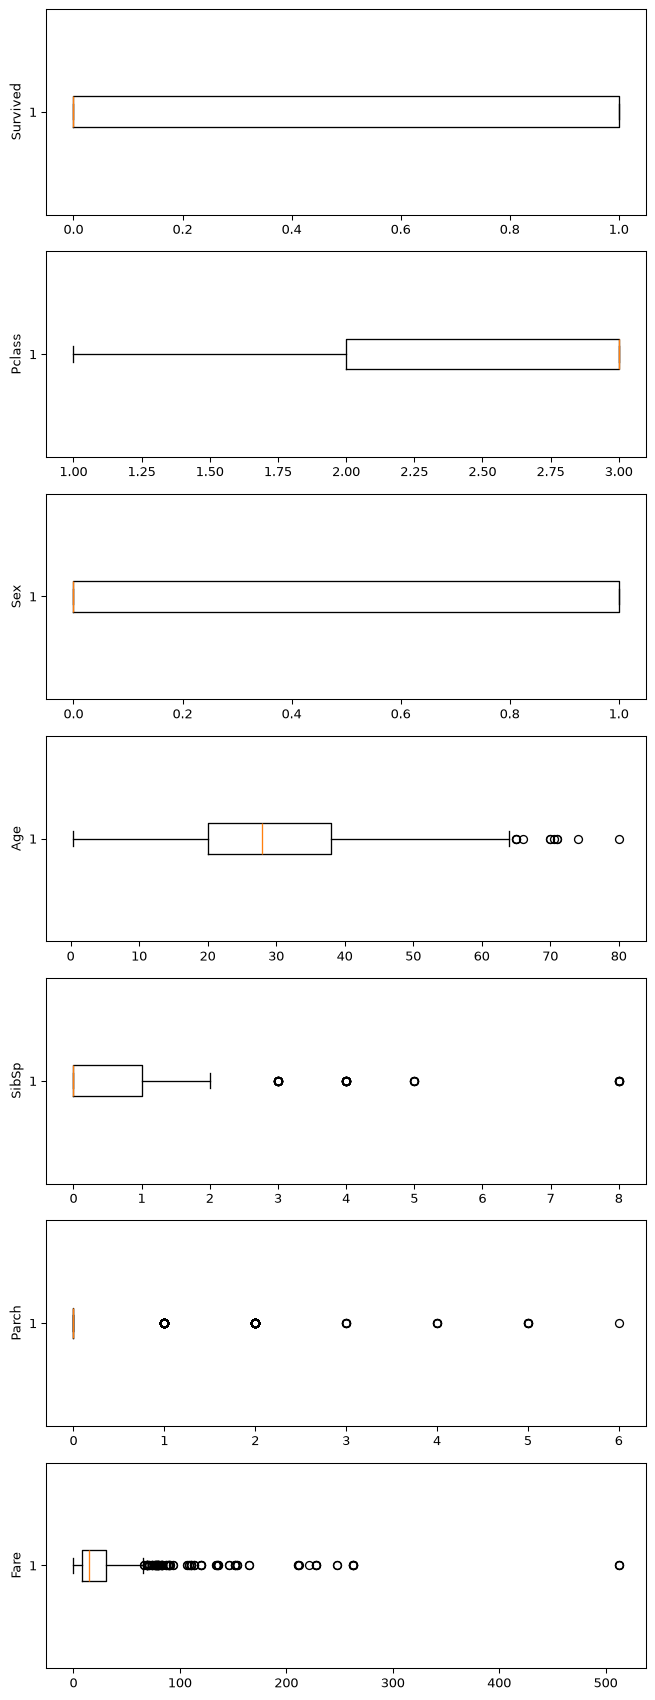

In [94]:
# Get list of numeric column names
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Create subplots only for those columns
fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(7, 18), dpi=95)

# Handle case when there's only one numeric column (axs won't be a list)
if len(numeric_cols) == 1:
    axs = [axs]

for i, col in enumerate(numeric_cols):
    # Remove any missing values to avoid issues
    data = df[col].dropna()
    axs[i].boxplot(data, vert=False)   # or use orientation='horizontal' to avoid deprecation warning
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Analysis
Generated boxplots for every numeric column in one grouped figure, giving a compact side-by-side view of spread and outliers across `Survived`, `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, and `Fare`. Notably, `Fare` should show a dramatic number of outlier points beyond its whisker given the max of $512.33 against a median of just $14.45, while `SibSp` and `Parch` will show most data compressed near 0 with a handful of high-value outliers.

**Hidden implication:** this cell also throws boxplots for columns that aren't meaningfully continuous — `Survived` (binary 0/1), `Pclass` (ordinal 1/2/3), and `Sex` (binary 0/1 after encoding) don't have a meaningful "spread" or "outlier" in the boxplot sense; a boxplot on a binary/categorical column just produces a flat box with no real interpretive value. Worth filtering `numeric_cols` down to genuinely continuous variables (`Age`, `Fare`, `SibSp`, `Parch`) for this plot to avoid cluttering the output with uninformative charts. Also note: this cell relies on `np.number`, so `import numpy as np` must exist earlier in the notebook — worth double-checking that import is present, since it wasn't in the initial library-import cell.

### Violin Plots

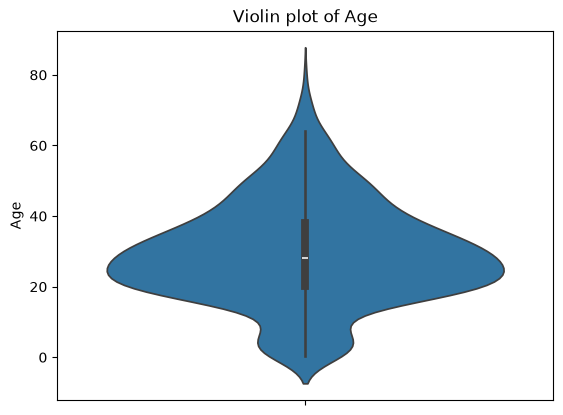

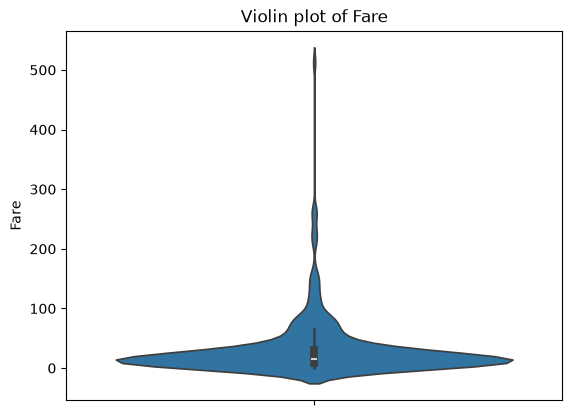

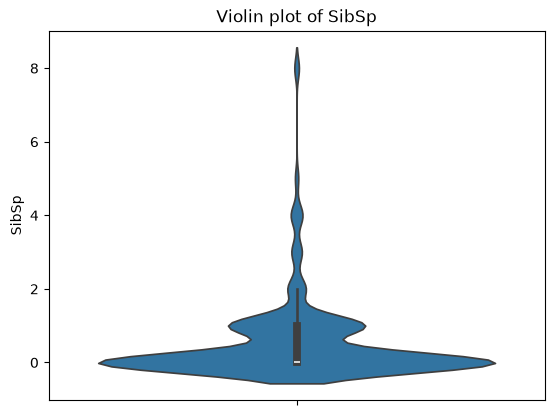

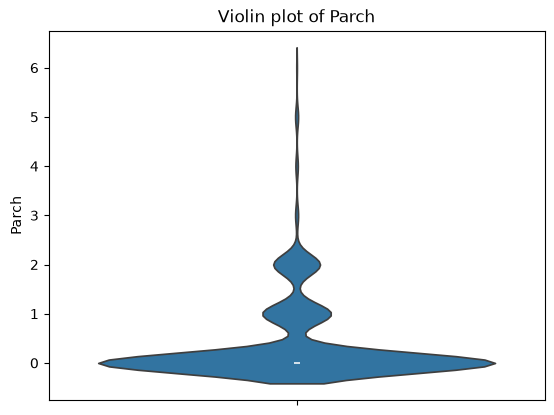

In [62]:
for col in num_cols:
    plt.figure()
    sns.violinplot(y=df[col].dropna())
    plt.title(f'Violin plot of {col}')
    plt.show()

### Analysis
Violin plots combine a boxplot's summary stats with a KDE's density shape for each of `Age`, `Fare`, `SibSp`, `Parch`. This should visually reinforce everything computed so far: `Age` as a moderately wide, roughly symmetric violin; `Fare` as a very narrow, tall violin near the bottom with a long thin stretch upward (reflecting its extreme skew/kurtosis); `SibSp`/`Parch` as violins bulging heavily at 0.

**Hidden implication:** because `Fare`'s distribution is so extremely right-skewed (skew ≈ 4.79) with a max over 35x its median, its violin plot will likely look visually uninformative on a linear scale — the density bulge will be squashed into a thin sliver near 0 while the outlier tail stretches the axis out. A log-scaled violin plot for `Fare` specifically would reveal its actual shape far better than the linear version being used here for all four columns uniformly.

### Outlier Detection (IQR)

In [102]:
Q1 = df ['Parch'].quantile(0.25)
Q3 = df['Parch'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['Parch']<Q1 - 1.5*IQR) | (df['Parch']> Q3 + 1.5*IQR)]
print(f"Number of Parch outliers: {len(outliers)}")




Number of Parch outliers: 213


### Analysis
Using the standard 1.5×IQR rule, **213 out of 891 records (23.9%)** are flagged as outliers in `Parch`. That's nearly 1 in 4 passengers being labeled an "outlier" — an unusually high proportion for a rule meant to catch rare extreme values.

**Hidden implication:** this large outlier count isn't really telling us something is wrong with the data — it's exposing a limitation of the IQR method on heavily zero-inflated discrete data. Since `Parch`'s Q1, median, and Q3 are all 0 (confirmed by the earlier `.describe()` output), the IQR itself is 0, making `upper_bound = 0`, so *any* passenger with `Parch ≥ 1` gets flagged as an outlier — even a fairly common value like 1 or 2. This means the 213 "outliers" mostly represent normal small families, not genuine anomalies. IQR is a poor fit for this kind of sparse count variable; a domain-informed threshold (e.g., flagging only `Parch > 4` or so) would be more meaningful than a blanket statistical rule here.

In [103]:
print(df['Parch'].quantile(0.25), df['Parch'].quantile(0.75))
df['Parch'].value_counts()

0.0 0.0


Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

### Analysis
Confirms directly what was inferred in the previous cell: both Q1 and Q3 of `Parch` are **0.0**, making the IQR itself 0 — which is why every non-zero value got flagged as an "outlier." The value counts show why: **678 passengers (76.1%) have `Parch = 0`**, with the remaining values dropping off sharply (118 have 1, 80 have 2, and only single-digit counts for 3–6).

**Hidden implication:** this is direct numeric proof that the 213 "outliers" from the previous cell are really just the ~24% of passengers who traveled with at least one parent/child — not statistical anomalies at all. It's a useful lesson to carry forward: IQR-based outlier detection should really only be applied to continuous, reasonably-distributed variables like `Age` or `Fare`, not sparse/discrete count variables like `Parch` and `SibSp` where the bulk of the mass sits at a single value.

### QQ Plot to Check Normality

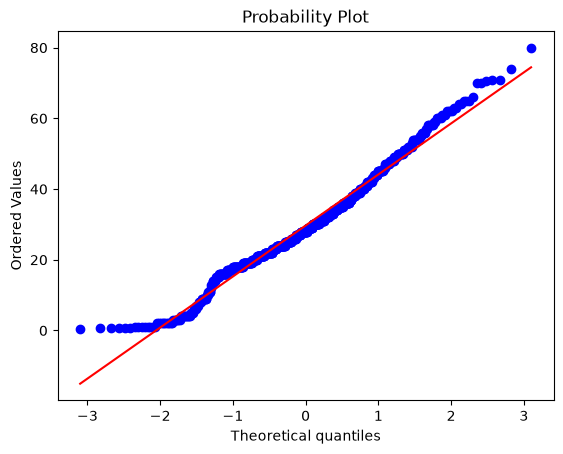

In [65]:
import scipy.stats as stats
stats.probplot(df['Age'].dropna(), dist="norm", plot=plt)
plt.show()

### Analysis
A QQ (quantile-quantile) plot compares `Age`'s actual quantiles against a theoretical normal distribution's quantiles — points falling along the diagonal reference line indicate normality, while deviation (especially curving away at the tails) indicates non-normality. Given `Age`'s mild skew (0.389) and near-zero excess kurtosis (0.178), the plot should show points hugging the line fairly closely through the middle, with only slight deviation curving upward at the upper tail (representing the older passengers pulling the distribution rightward).

**Hidden implication:** this is the first formal normality check in the notebook, and it's a good visual complement to the skew/kurtosis numbers from earlier — but it's only run on `Age`, not `Fare`. Given `Fare`'s extreme skew (4.79) and kurtosis (33.4), its QQ plot would show dramatic, obvious deviation from the reference line (a sharply curving tail), and would make a much stronger visual case for why `Fare` needs transformation before use in any model assuming normality (e.g., linear regression). Worth adding a QQ plot for `Fare` too, for a fuller normality picture across the numeric variables.

### Cumulative Distribution Function (CDF) Plot

Text(0.5, 1.0, 'Empirical CDF of Age')

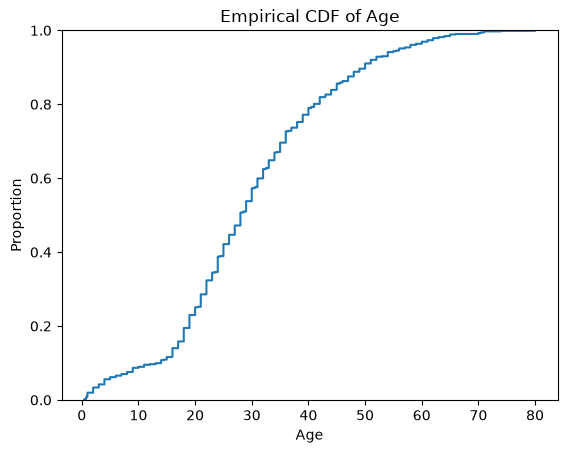

In [66]:
sns.ecdfplot(data=df, x='Age')
plt.title('Empirical CDF of Age')

### Analysis
Plots the empirical CDF of `Age`, showing the cumulative proportion of passengers at or below each age value. Given the median of 28 (from `.describe()` earlier), the curve should cross the 50% mark right around age 28, with roughly 25% of passengers below ~20 and 75% below ~38 (matching the Q1/Q3 values from the summary statistics).

**Hidden implication:** the ECDF is a useful closing visual because, unlike the histogram or KDE, it isn't sensitive to bin width or smoothing bandwidth — it's an exact, distortion-free representation of the data. It directly confirms one practical takeaway from this whole univariate pass: `Age`'s missing 177 values (19.9%) are silently excluded here via the same `dropna()`-by-default behavior seen throughout the notebook, so this CDF describes only the ~80% of passengers with recorded ages — any imputation choice made later should be validated against this exact empirical curve to make sure it doesn't distort the true underlying shape.